# Descripition

Medical Insurance Cost Prediction
In this project, we analyze how personal attributes and lifestyle choices impact medical insurance costs. The dataset includes information about age, gender, BMI, family size, smoking habits, geographic location, and medical expenses. By studying these factors, we aim to identify key influences on insurance charges and build a predictive model to estimate future healthcare costs.

Key Objectives:

✔ Understand how different factors affect medical expenses.

✔ Identify trends, such as how smoking or BMI influences insurance costs.

✔ Build a machine learning model to predict insurance charges based on personal and geographic data.

#### Data card
- https://www.kaggle.com/datasets/willianoliveiragibin/healthcare-insurance/data
### App
- https://huggingface.co/spaces/kanneboinakumar/Insurance-Analysis

<a href="/imgres?q=health%20insurance&amp;imgurl=https%3A%2F%2Fjupiter.money%2Fblog%2Fwp-content%2Fuploads%2F2024%2F06%2FWhat_is_Health_Insurance.jpg&amp;imgrefurl=https%3A%2F%2Fjupiter.money%2Fblog%2Fhealth-insurance%2F&amp;docid=HzLQFI9nu9b6lM&amp;tbnid=lgoZ3_A2MAhO6M&amp;vet=12ahUKEwiHhZnuvJyLAxWQrlYBHXpyLBAQM3oECH8QAA..i&amp;w=940&amp;h=526&amp;hcb=2&amp;ved=2ahUKEwiHhZnuvJyLAxWQrlYBHXpyLBAQM3oECH8QAA"><div class="F0uyec" jsdata="j0Opre;lgoZ3_A2MAhO6M;AlR7U4" jscontroller="qKrDxc" jsshadow="" role="button" tabindex="0" jsaction="rcuQ6b:npT2md;h5M12e;jGQF0b:kNqZ1c;mouseover:UI3Kjd" data-viewer-entrypoint="1" data-vhid="lgoZ3_A2MAhO6M"><div jsslot=""><div class="H8Rx8c" style="height:180px"><g-img style="max-height:168px;max-width:300px" class="mNsIhb">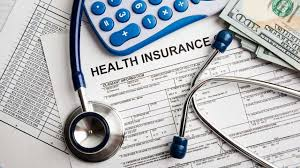</g-img><div class="cC9Rib"></div></div></div></div></a>

## 1.Requriment Package Loading

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error
from joblib import dump,load

## 2.Understand the Dataset
- first check its structure, missing values, and key features

In [ ]:
insurance_df=pd.read_csv('insurance.csv')
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
print(f"shape of insurance data : {insurance_df.shape}")
columns = insurance_df.columns
l=[]
for col in columns:
    dtype = insurance_df[col].dtype
    nunique = insurance_df[col].nunique()
    null_count = insurance_df[col].isnull().sum()
    l.append([dtype,nunique,null_count])
pd.DataFrame(l,columns=["dtype","nunique","null_count"],index=columns)

shape of insurance data : (1338, 7)


,dtype,nunique,null_count
age,int64,47,0
sex,object,2,0
bmi,float64,548,0
children,int64,6,0
smoker,object,2,0
region,object,4,0
charges,float64,1337,0


## 3.Preprocess the Data
- Handle missing values
- scale features
- encode categorical variables
- Drop unwanted columns

### 3.1.Catgorial and Numerical Colums Superation

In [ ]:
cat_cols = insurance_df.select_dtypes(include=['object']).columns.tolist()
num_cols = insurance_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Categorical columns:', cat_cols, '\nNumerical columns:', num_cols)

Categorical columns: ['sex', 'smoker', 'region'] 
Numerical columns: ['age', 'bmi', 'children', 'charges']


### 3.2.Catgorial Analysis

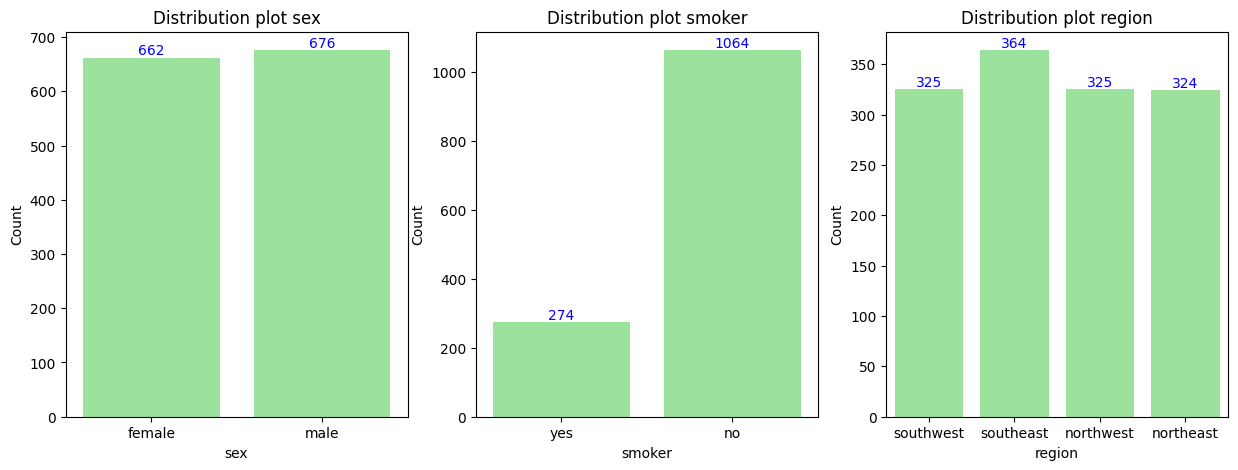

In [ ]:
plt.figure(figsize=(15,5))
for i in range(len(cat_cols)):
    count = insurance_df[cat_cols[i]].value_counts().keys()
    plt.subplot(1,3, i + 1)
    ax = sns.countplot(data=insurance_df,x=insurance_df[cat_cols[i]],color='lightgreen')
    ax.bar_label(ax.containers[0],color='blue')
    ax.set_title(f'Distribution plot {cat_cols[i]}')
    ax.set_xlabel(cat_cols[i])
    ax.set_ylabel('Count')


### 3.3.Numarical Analysis

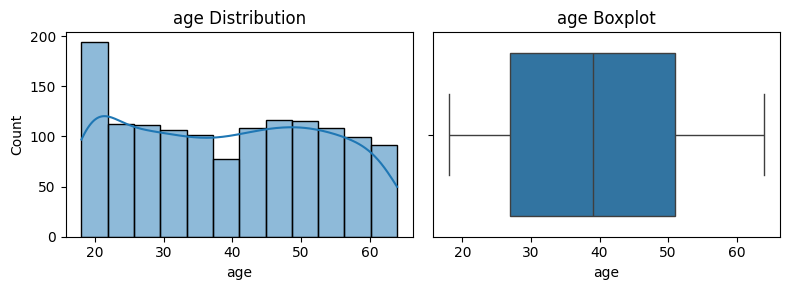

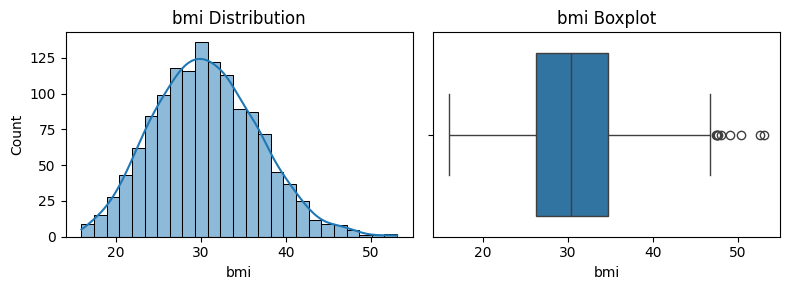

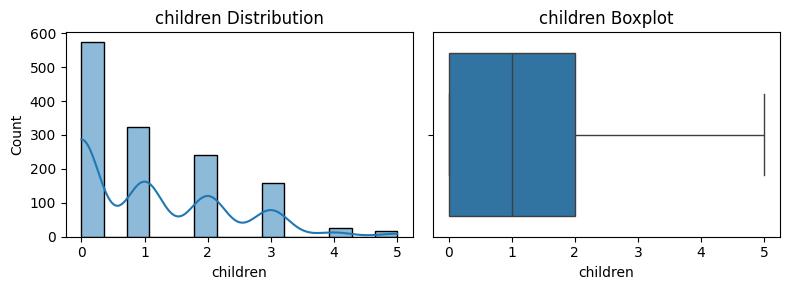

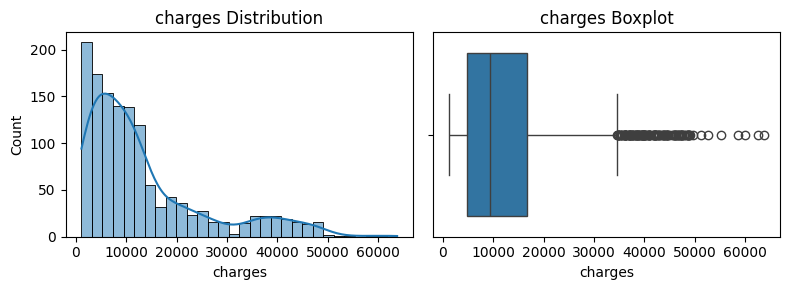

In [ ]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    # Plot the distribution plot in the first subplot
    sns.histplot(insurance_df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'{col} Distribution')

    # Plot the boxplot in the second subplot
    sns.boxplot(x=insurance_df[col], ax=axes[1])
    axes[1].set_title(f'{col} Boxplot')

    # Display the plots
    plt.tight_layout()
    plt.show()

In [ ]:
# def remove_outliers_iqr(df, columns):
#     for col in columns:
#         Q1 = df[col].quantile(0.25)
#         Q3 = df[col].quantile(0.75)
#         IQR = Q3 - Q1
#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR
#         df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
#     return df

# # Apply outlier removal
# insurance_df_cleaned = remove_outliers_iqr(insurance_df, num_cols)

# # Check new shape after outlier removal
# print("Original Shape:", insurance_df.shape)
# print("New Shape after Outlier Removal:", insurance_df_cleaned.shape)

In [ ]:
insurance_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


### 3.4.LabelEncoder

In [ ]:
encoder_d={}
for col in insurance_df[cat_cols]:
    encoder=LabelEncoder()
    insurance_df[col]=encoder.fit_transform(insurance_df[col])
    encoder_d[col]=encoder

### 3.5.Save LabelEncoder

In [ ]:
dump(encoder_d,'encoder_d.joblib')

['encoder_d.joblib']

### 3.6.Correlation metrix

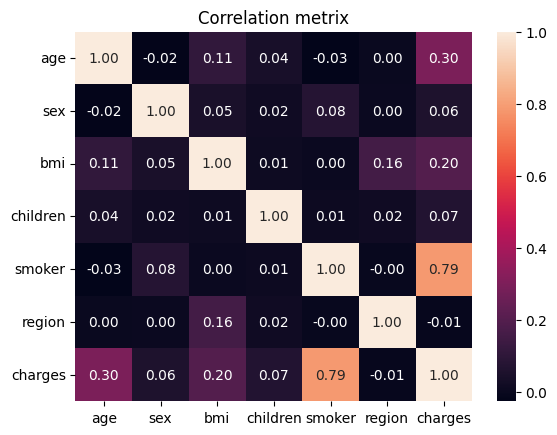

In [ ]:
sns.heatmap(insurance_df.corr(),annot=True,fmt=".2f")
plt.title("Correlation metrix")
plt.show()

### 3.8.Train Test Split

In [ ]:
X=insurance_df.drop(columns='charges')
y=insurance_df['charges']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)
print(X_test.shape)
print(y_test.shape)
print(X_train.shape)
print(y_train.shape)


(268, 6)
(268,)
(1070, 6)
(1070,)


## 4.Model Building

In [ ]:
lr=LinearRegression()
lr.fit(X_train,y_train)

dt=DecisionTreeRegressor()
dt.fit(X_train,y_train)

Rf=RandomForestRegressor()
Rf.fit(X_train,y_train)

RandomForestRegressor()

## 5.Evaluaction of Model

In [ ]:
def report(model,X,y):
    predict=model.predict(X)
    r2=r2_score(predict,y)
    rmse=root_mean_squared_error(predict,y)
    mae=mean_absolute_error(predict,y)
    adj_r2=1 - ((1 - r2) * ( X.shape[0]- 1) / (X.shape[0] - X.shape[1] - 1))
    return [rmse,mae,r2,adj_r2]
models=[lr,dt,Rf]
l=[]
for model in models:
    l.append(report(model,X_train,y_train))
print('Train_Data_Report')
Train_Data_Report=pd.DataFrame(l,index=['lr','dt','Rf'],columns=['rmse','mae','r2','adj_r2'])
Train_Data_Report

Train_Data_Report


,rmse,mae,r2,adj_r2
lr,6105.789320,4208.762029,0.651755,0.649789
dt,494.205984,29.572515,0.998305,0.998295
Rf,1893.922931,1041.883251,0.972968,0.972815


In [ ]:
l=[]
for model in models:
    l.append(report(model,X_test,y_test))
print('Test_Data_Report')
Test_Data_Report=pd.DataFrame(l,index=['lr','dt','Rf'],columns=['r2','rmse','mae','adj_r2'])
Test_Data_Report

Test_Data_Report


,r2,rmse,mae,adj_r2
lr,5799.587091,4186.508898,0.708617,0.701918
dt,6713.129458,3043.187433,0.754057,0.748403
Rf,4635.528583,2534.285031,0.853409,0.850039


## 6.Save Best Model

In [ ]:
from joblib import dump
dump(Rf,'Rf_model.joblib')

['Rf_model.joblib']